In [1]:
import os
import sys
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

print(os.getcwd())

/Users/daniehbenotman/Desktop/worldbank_tableau_project/notebooks


In [2]:
OUTPUT_DIR = Path("/Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/classification")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR

PosixPath('/Users/daniehbenotman/Desktop/worldbank_tableau_project/outputs/classification')

In [3]:
os.chdir("/Users/daniehbenotman/Desktop/worldbank_tableau_project")
print("✅ Working directory changed to:", os.getcwd())

✅ Working directory changed to: /Users/daniehbenotman/Desktop/worldbank_tableau_project


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest
from pathlib import Path

plt.style.use("seaborn-v0_8-whitegrid")


# Data Imports and Data Cleaninng for Merge 

In [5]:
ef = pd.read_csv("data/event_flags_country_year.csv")
af = pd.read_csv("data/anomaly_features.csv")

In [6]:
df = ef.merge(
    af,
    on="country_name",
    how="left"
)


In [7]:
df.head()

,Unnamed: 0,country_name,year,flag_global_crisis,flag_regional_crisis,flag_country_conflict,flag_country_crisis,flag_reform_period,event_type_primary,Cluster,Cluster_Name,anomaly_flag,anomaly_intensity,Anomaly_Driver
0,0,Algeria,2000,0,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
1,1,Algeria,2001,0,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
2,2,Algeria,2002,0,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
3,3,Algeria,2003,0,0,1,0,0,conflict,3,North African Reformers,0,0.0,PC3
4,4,Algeria,2004,0,0,0,1,1,crisis,3,North African Reformers,0,0.0,PC3


In [8]:
df.columns

Index(['Unnamed: 0', 'country_name', 'year', 'flag_global_crisis',
       'flag_regional_crisis', 'flag_country_conflict', 'flag_country_crisis',
       'flag_reform_period', 'event_type_primary', 'Cluster', 'Cluster_Name',
       'anomaly_flag', 'anomaly_intensity', 'Anomaly_Driver'],
      dtype='object')

## Features Audit

In [9]:
fe = pd.read_csv("data/fe_features_country_year.csv")

In [10]:
fe.head()

,country_name,year,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,...,rolling_std_5y_mean,coef_variation_mean,regional_deviation_mean,regional_deviation_std_mean,n_rows,n_indicators_total,n_indicators_present,n_categories_present,country_max_indicators,coverage_ratio_country
0,Algeria,2000,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0.000000,17.242192,33493.791963,0.002206,42,42,42,8,42,1.0
1,Algeria,2001,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,11195.073925,17.242192,31338.463493,-0.011879,42,42,42,8,42,1.0
2,Algeria,2002,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,15688.278460,17.242192,28976.401640,-0.009692,42,42,42,8,42,1.0
3,Algeria,2003,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,20260.444556,17.242192,26599.445304,-0.028253,42,42,42,8,42,1.0
4,Algeria,2004,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,25161.588400,17.242192,24660.001719,-0.144521,42,42,42,8,42,1.0


In [11]:
fe.shape


(432, 77)

In [12]:
fe.columns

Index(['country_name', 'year', 'cat_Demographics_trend_slope',
       'cat_Economy_trend_slope', 'cat_Education_trend_slope',
       'cat_Governance_trend_slope', 'cat_Health_trend_slope',
       'cat_Labor_trend_slope', 'cat_LegalAutonomy_trend_slope',
       'cat_WBL_trend_slope', 'cat_Demographics_cagr', 'cat_Economy_cagr',
       'cat_Education_cagr', 'cat_Governance_cagr', 'cat_Health_cagr',
       'cat_Labor_cagr', 'cat_LegalAutonomy_cagr', 'cat_WBL_cagr',
       'cat_Demographics_momentum', 'cat_Economy_momentum',
       'cat_Education_momentum', 'cat_Governance_momentum',
       'cat_Health_momentum', 'cat_Labor_momentum',
       'cat_LegalAutonomy_momentum', 'cat_WBL_momentum',
       'cat_Demographics_rolling_std_5y', 'cat_Economy_rolling_std_5y',
       'cat_Education_rolling_std_5y', 'cat_Governance_rolling_std_5y',
       'cat_Health_rolling_std_5y', 'cat_Labor_rolling_std_5y',
       'cat_LegalAutonomy_rolling_std_5y', 'cat_WBL_rolling_std_5y',
       'cat_Demographics_sp

In [13]:
KEYS = ["country_name", "year"]

In [14]:
# Quick schema check
missing_keys = [k for k in KEYS if k not in fe.columns]
if missing_keys:
    raise KeyError(f"Missing merge keys: {missing_keys}")

print("Shape:", fe.shape)
print("Year range:", fe["year"].min(), "->", fe["year"].max(), "| unique years:", fe["year"].nunique())
print("Unique countries:", fe["country_name"].nunique())

Shape: (432, 77)
Year range: 2000 -> 2023 | unique years: 24
Unique countries: 18


In [15]:
expected = fe["country_name"].nunique() * fe["year"].nunique()
print("Expected rows (countries * years):", expected, "| Actual rows:", len(fe))


Expected rows (countries * years): 432 | Actual rows: 432


In [16]:
expected = fe["country_name"].nunique() * fe["year"].nunique()
print("Expected rows (countries * years):", expected, "| Actual rows:", len(fe))


Expected rows (countries * years): 432 | Actual rows: 432


In [17]:
missing_rate = fe.isna().mean().sort_values(ascending=False)
print("\nTop missing-rate columns:")
print(missing_rate.head(20))


Top missing-rate columns:
country_name                        0.0
cat_WBL_dip                         0.0
cat_LegalAutonomy_coef_variation    0.0
cat_Labor_coef_variation            0.0
cat_Health_coef_variation           0.0
cat_Governance_coef_variation       0.0
cat_Education_coef_variation        0.0
cat_Economy_coef_variation          0.0
cat_Demographics_coef_variation     0.0
cat_LegalAutonomy_dip               0.0
cat_Labor_spike                     0.0
cat_Labor_dip                       0.0
cat_Health_dip                      0.0
cat_Governance_dip                  0.0
cat_Education_dip                   0.0
cat_Economy_dip                     0.0
cat_Demographics_dip                0.0
cat_WBL_spike                       0.0
cat_WBL_coef_variation              0.0
abs_yoy_change_mean                 0.0
dtype: float64


In [18]:
num_cols = fe.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in ["year"]]  # keep year separate if you want

inf_mask = np.isinf(fe[num_cols]).any(axis=0)
inf_cols = inf_mask[inf_mask].index.tolist()

print("\nColumns containing +/-inf:", len(inf_cols))
if inf_cols:
    print(inf_cols[:30])
    # Replace inf with NaN so you can treat it consistently
    fe[inf_cols] = fe[inf_cols].replace([np.inf, -np.inf], np.nan)



Columns containing +/-inf: 0


In [19]:
# Constant columns = only 1 unique value (ignoring NaN)
nunique_non_na = fe.drop(columns=KEYS).nunique(dropna=True).sort_values()
constant_cols = nunique_non_na[nunique_non_na <= 1].index.tolist()

print("\nConstant cols (nunique<=1):", len(constant_cols))
if constant_cols:
    print(constant_cols[:30])



Constant cols (nunique<=1): 8
['coverage_ratio_country', 'n_categories_present', 'n_indicators_present', 'n_indicators_total', 'n_rows', 'cat_LegalAutonomy_cagr', 'country_max_indicators', 'cat_LegalAutonomy_rolling_std_5y']


In [20]:
# Near-constant: one value dominates (e.g., 99.5% same)
near_constant_cols = []
for c in fe.columns:
    if c in KEYS:
        continue
    vc = fe[c].value_counts(dropna=True, normalize=True)
    if len(vc) > 0 and vc.iloc[0] >= 0.995:
        near_constant_cols.append(c)
        
print("\nNear-constant cols (top value >= 99.5%):", len(near_constant_cols))
if near_constant_cols:
    print(near_constant_cols[:30])



Near-constant cols (top value >= 99.5%): 9
['cat_LegalAutonomy_cagr', 'cat_LegalAutonomy_momentum', 'cat_LegalAutonomy_rolling_std_5y', 'n_rows', 'n_indicators_total', 'n_indicators_present', 'n_categories_present', 'country_max_indicators', 'coverage_ratio_country']


In [21]:
coverage_cols = [
    "n_rows", "n_indicators_total", "n_indicators_present", "n_categories_present",
    "country_max_indicators", "coverage_ratio_country"
]
coverage_cols = [c for c in coverage_cols if c in fe.columns]

print("\nCoverage columns present:", coverage_cols)

if coverage_cols:
    print("\nCoverage summary (overall):")
    print(fe[coverage_cols].describe().T[["min","mean","std","max"]])

    print("\nCoverage variance by country (std across years):")
    tmp = fe.groupby("country_name")[coverage_cols].std(numeric_only=True)
    print(tmp.sort_values(by=coverage_cols[0], ascending=False).head(10)) 



Coverage columns present: ['n_rows', 'n_indicators_total', 'n_indicators_present', 'n_categories_present', 'country_max_indicators', 'coverage_ratio_country']

Coverage summary (overall):
                         min  mean  std   max
n_rows                  42.0  42.0  0.0  42.0
n_indicators_total      42.0  42.0  0.0  42.0
n_indicators_present    42.0  42.0  0.0  42.0
n_categories_present     8.0   8.0  0.0   8.0
country_max_indicators  42.0  42.0  0.0  42.0
coverage_ratio_country   1.0   1.0  0.0   1.0

Coverage variance by country (std across years):
                      n_rows  n_indicators_total  n_indicators_present  \
country_name                                                             
Algeria                  0.0                 0.0                   0.0   
Bahrain                  0.0                 0.0                   0.0   
West Bank and Gaza       0.0                 0.0                   0.0   
United Arab Emirates     0.0                 0.0                   0.

In [22]:
missing_rate2 = fe.isna().mean().sort_values(ascending=False)

In [23]:
HIGH_MISSING_THRESHOLD = 0.40  # drop columns missing > 40%
high_missing_cols = missing_rate2[missing_rate2 > HIGH_MISSING_THRESHOLD].index.tolist()

drop_cols = sorted(set(constant_cols + high_missing_cols))
print("\nDrop candidates:")
print(" - High missing:", len(high_missing_cols))
print(" - Constant:", len(constant_cols))
print(" - TOTAL drop_cols:", len(drop_cols))



Drop candidates:
 - High missing: 0
 - Constant: 8
 - TOTAL drop_cols: 8


constant columns are safe to drop before classification.

near-constant columns are usually also safe to drop,


In [24]:
KEYS = ["country_name", "year"]

drop_cols = sorted(set(constant_cols + near_constant_cols))

fe_clean = fe.drop(columns=[c for c in drop_cols if c in fe.columns], errors="ignore")

print("Before:", fe.shape)
print("After :", fe_clean.shape)
print("Dropped:", drop_cols)

# Final sanity: keys still there
assert all(k in fe_clean.columns for k in KEYS), "Missing merge keys after cleaning"

fe_clean.to_csv("data/fe_features_for_classification.csv", index=False)


Before: (432, 77)
After : (432, 68)
Dropped: ['cat_LegalAutonomy_cagr', 'cat_LegalAutonomy_momentum', 'cat_LegalAutonomy_rolling_std_5y', 'country_max_indicators', 'coverage_ratio_country', 'n_categories_present', 'n_indicators_present', 'n_indicators_total', 'n_rows']


In [25]:
fd = pd.read_csv("data/fe_features_for_classification.csv")

## Final Merge

In [26]:
fd.head()

,country_name,year,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,...,spike_sum,spike_rate,dip_sum,dip_rate,outlier_sum,outlier_rate,rolling_std_5y_mean,coef_variation_mean,regional_deviation_mean,regional_deviation_std_mean
0,Algeria,2000,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,4,0.095238,4,0.095238,13,0.309524,0.000000,17.242192,33493.791963,0.002206
1,Algeria,2001,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,3,0.071429,0,0.000000,11,0.261905,11195.073925,17.242192,31338.463493,-0.011879
2,Algeria,2002,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0.000000,0,0.000000,9,0.214286,15688.278460,17.242192,28976.401640,-0.009692
3,Algeria,2003,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0.000000,0,0.000000,8,0.190476,20260.444556,17.242192,26599.445304,-0.028253
4,Algeria,2004,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0.000000,0,0.000000,7,0.166667,25161.588400,17.242192,24660.001719,-0.144521


In [27]:
KEYS = ["country_name", "year"]
df = df.drop(columns=[c for c in ["Unnamed: 0", "index"] if c in df.columns], errors="ignore")
df["country_name"] = df["country_name"].astype(str).str.strip()
df["year"] = df["year"].astype(int)

In [28]:
event_flag_cols = [
    "flag_global_crisis",
    "flag_regional_crisis",
    "flag_country_conflict",
    "flag_country_crisis",
    "flag_reform_period",
]

optional_context_cols = [
    "event_type_primary",  # categorical (optional)
    "Cluster",             # optional
    "Cluster_Name",        # optional
]

label_cols = [
    "anomaly_flag",
    "anomaly_intensity",
]

keep_ev_cols = KEYS + [c for c in (event_flag_cols + optional_context_cols + label_cols + ["Anomaly_Driver"]) if c in df.columns]
df = df[keep_ev_cols].copy()

In [29]:
if df.duplicated(KEYS).any():
    agg = {}
    for c in df.columns:
        if c in KEYS:
            continue
        if c.startswith("flag_") or c in label_cols or c == "Cluster":
            agg[c] = "max"
        else:
            agg[c] = "first"
    df = df.groupby(KEYS, as_index=False).agg(agg)

In [30]:
df.head()

,country_name,year,flag_global_crisis,flag_regional_crisis,flag_country_conflict,flag_country_crisis,flag_reform_period,event_type_primary,Cluster,Cluster_Name,anomaly_flag,anomaly_intensity,Anomaly_Driver
0,Algeria,2000,0,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
1,Algeria,2001,0,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
2,Algeria,2002,0,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
3,Algeria,2003,0,0,1,0,0,conflict,3,North African Reformers,0,0.0,PC3
4,Algeria,2004,0,0,0,1,1,crisis,3,North African Reformers,0,0.0,PC3


In [31]:
fe = fd.copy()

In [32]:
fe["country_name"] = fe["country_name"].astype(str).str.strip()
fe["year"] = fe["year"].astype(int)

# keep only keys + numeric feature columns (drops text cols automatically)
feature_cols = [c for c in fe.columns if c in KEYS or pd.api.types.is_numeric_dtype(fe[c])]
fe_clean = fe[feature_cols].copy()


In [33]:
if fe_clean.duplicated(KEYS).any():
    num_cols = [c for c in fe_clean.columns if c not in KEYS]
    fe_clean = fe_clean.groupby(KEYS, as_index=False)[num_cols].mean()

In [34]:
df_cls = fe_clean.merge(df, on=KEYS, how="left")

# (optional) ensure flags are 0/1 and fill missing flags with 0
for c in event_flag_cols:
    if c in df_cls.columns:
        df_cls[c] = df_cls[c].fillna(0).astype(int)

In [35]:
print(df_cls.shape)

(432, 79)


# Data

In [36]:
df_cls.head()

,country_name,year,cat_Demographics_trend_slope,cat_Economy_trend_slope,cat_Education_trend_slope,cat_Governance_trend_slope,cat_Health_trend_slope,cat_Labor_trend_slope,cat_LegalAutonomy_trend_slope,cat_WBL_trend_slope,...,flag_regional_crisis,flag_country_conflict,flag_country_crisis,flag_reform_period,event_type_primary,Cluster,Cluster_Name,anomaly_flag,anomaly_intensity,Anomaly_Driver
0,Algeria,2000,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
1,Algeria,2001,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
2,Algeria,2002,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0,0,0,none,3,North African Reformers,0,0.0,PC3
3,Algeria,2003,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,1,0,0,conflict,3,North African Reformers,0,0.0,PC3
4,Algeria,2004,230464.499974,60.441547,-0.001908,0.372635,-0.258759,-0.191337,0.005901,0.73288,...,0,0,1,1,crisis,3,North African Reformers,0,0.0,PC3


# X-Y Featurs - Label 

In [37]:
df = df_cls.copy()  

# -------------------
# 1) Define targets
# -------------------
y_class = df["anomaly_flag"].astype(int)
y_reg   = df["anomaly_intensity"]  # keep float

# -------------------
# 2) Define columns to exclude from X
# -------------------
drop_from_X = [
    "country_name",
    "anomaly_flag",
    "anomaly_intensity",
    "Anomaly_Driver",
    "year"
]


# optional: keep only one of Cluster / Cluster_Name (recommended: keep name)
drop_from_X.append("Cluster")  # drop numeric id if keeping Cluster_Name

# -------------------
# 3) Build X
# -------------------
X = df.drop(columns=[c for c in drop_from_X if c in df.columns], errors="ignore").copy()

# -------------------
# 4) Handle categoricals (one-hot)
# -------------------
cat_cols = [c for c in ["event_type_primary", "Cluster_Name"] if c in X.columns]
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("X shape:", X.shape)
print("y_class distribution:\n", y_class.value_counts(dropna=False))


X shape: (432, 78)
y_class distribution:
 anomaly_flag
0    360
1     72
Name: count, dtype: int64


##### Label distribution is imbalanced:
That’s ~17% positives → imbalanced.
So don’t judge with accuracy. Use:
Precision / Recall
F1
PR-AUC

And consider class_weight='balanced' (LR) or balanced sampling (RF).

In [38]:
years = np.sort(df["year"].unique())
n_years = len(years)

# Use last ~20% of years as test (time-aware holdout)
cut = int(np.floor(n_years * 0.8))
train_years = years[:cut]
test_years  = years[cut:]

train_idx = df["year"].isin(train_years)
test_idx  = df["year"].isin(test_years)

X_train_raw = X.loc[train_idx].copy()
y_train = y_class.loc[train_idx].copy()

X_test_raw = X.loc[test_idx].copy()
y_test = y_class.loc[test_idx].copy()

print("Train years:", train_years.min(), "->", train_years.max(), "| rows:", len(X_train_raw))
print("Test  years:", test_years.min(), "->", test_years.max(), "| rows:", len(X_test_raw))
print("\nTrain label distribution:\n", y_train.value_counts())
print("\nTest label distribution:\n", y_test.value_counts())


Train years: 2000 -> 2018 | rows: 342
Test  years: 2019 -> 2023 | rows: 90

Train label distribution:
 anomaly_flag
0    285
1     57
Name: count, dtype: int64

Test label distribution:
 anomaly_flag
0    75
1    15
Name: count, dtype: int64


#### Note: 
If you predict “no anomaly” for everything, you’ll get accuracy ≈ 83.3% (because only 16.7% are 1s).
So any model bragging about ~83% accuracy might be doing nothing useful.

That’s why your main story will be: “We improve recall/PR-AUC over the naive baseline while keeping precision acceptable.”

In [39]:
# df is your merged classification dataframe
KEYS = ["country_name", "year"]
TARGETS = ["anomaly_flag", "anomaly_intensity"]

# Categorical = object/category dtype columns (excluding keys/targets)
cat_cols = (
    df.select_dtypes(include=["object", "category"])
      .columns.difference(KEYS + TARGETS)
      .tolist()
)

# Numeric = number dtype columns (excluding keys/targets)
num_cols = (
    df.select_dtypes(include=["number"])
      .columns.difference(KEYS + TARGETS)
      .tolist()
)

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols[:20], "... total:", len(num_cols))


Categorical columns: ['Anomaly_Driver', 'Cluster_Name', 'event_type_primary']
Numeric columns: ['Cluster', 'abs_yoy_change_mean', 'abs_yoy_change_median', 'abs_yoy_change_std', 'cat_Demographics_cagr', 'cat_Demographics_coef_variation', 'cat_Demographics_dip', 'cat_Demographics_momentum', 'cat_Demographics_rolling_std_5y', 'cat_Demographics_spike', 'cat_Demographics_trend_slope', 'cat_Economy_cagr', 'cat_Economy_coef_variation', 'cat_Economy_dip', 'cat_Economy_momentum', 'cat_Economy_rolling_std_5y', 'cat_Economy_spike', 'cat_Economy_trend_slope', 'cat_Education_cagr', 'cat_Education_coef_variation'] ... total: 72


In [40]:
df.drop(columns='Cluster', inplace=True)

In [41]:
num_cols =  [c for c in X_train_raw.columns if c not in cat_cols]

In [42]:
bool_cols = X_train_raw.select_dtypes(include=["bool"]).columns.tolist()
print("Boolean cols inside X_train_raw:", bool_cols)


Boolean cols inside X_train_raw: ['event_type_primary_crisis', 'event_type_primary_none', 'event_type_primary_reform', 'Cluster_Name_High-Income Empowerers', 'Cluster_Name_Lebanon Outlier', 'Cluster_Name_North African Reformers', 'Cluster_Name_Palestine']


In [43]:
import numpy as np

num_cols_for_audit = (
    X_train_raw
    .select_dtypes(include=[np.number])     # numeric
    .select_dtypes(exclude=["bool"])        # but NOT bool
    .columns
    .tolist()
)

scale_audit = pd.DataFrame({
    "mean": X_train_raw[num_cols_for_audit].mean(),
    "std":  X_train_raw[num_cols_for_audit].std(),
    "min":  X_train_raw[num_cols_for_audit].min(),
    "max":  X_train_raw[num_cols_for_audit].max(),
}).sort_values("std", ascending=False)

scale_audit["range"] = scale_audit["max"] - scale_audit["min"]
scale_audit["abs_mean"] = scale_audit["mean"].abs()

# quick ratios
std_ratio = scale_audit["std"].max() / (scale_audit["std"][scale_audit["std"]>0].min())
range_ratio = scale_audit["range"].max() / (scale_audit["range"][scale_audit["range"]>0].min())

print("STD ratio (max/min nonzero):", std_ratio)
print("RANGE ratio (max/min nonzero):", range_ratio)

scale_audit.head(15)


STD ratio (max/min nonzero): 66629372.54845764
RANGE ratio (max/min nonzero): 93768935.5408014


,mean,std,min,max,range,abs_mean
regional_deviation_mean,0.000000,449851.425581,-801743.313440,1.551216e+06,2.352960e+06,0.000000
cat_Demographics_rolling_std_5y,223145.997039,243816.331762,0.000000,1.126693e+06,1.126693e+06,223145.997039
cat_Demographics_trend_slope,150580.038820,157044.363194,14026.204516,6.144760e+05,6.004498e+05,150580.038820
abs_yoy_change_std,70130.318259,76513.925131,0.000000,3.387110e+05,3.387110e+05,70130.318259
rolling_std_5y_mean,24930.544129,27035.752074,0.000000,1.251995e+05,1.251995e+05,24930.544129
abs_yoy_change_mean,10881.051561,11781.021230,0.000000,5.226709e+04,5.226709e+04,10881.051561
cat_Education_trend_slope,3016.353403,8768.311725,-4534.666792,2.832192e+04,3.285659e+04,3016.353403
cat_Education_rolling_std_5y,1066.376313,6512.919599,0.000000,6.493463e+04,6.493463e+04,1066.376313
cat_Economy_rolling_std_5y,983.043179,1748.756701,0.000000,1.061640e+04,1.061640e+04,983.043179
cat_Governance_rolling_std_5y,317.220788,1603.636872,0.000000,1.294167e+04,1.294167e+04,317.220788


In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline


cat_cols = [c for c in ['event_type_primary', 'Cluster_Name'] if c in X_train_raw.columns]
num_cols = [c for c in X_train_raw.columns if c not in cat_cols]

numeric_pipe = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_cols),
    ],
    remainder="drop"
)

print("Numeric cols:", len(num_cols))

Numeric cols: 78


In [45]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="liblinear"
)

logreg_pipe = Pipeline(steps=[
    ("preprocess", preprocess),  # your scaler + imputer
    ("model", log_reg)
])

# Train
logreg_pipe.fit(X_train_raw, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [46]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred_lr = logreg_pipe.predict(X_test_raw)
y_prob_lr = logreg_pipe.predict_proba(X_test_raw)[:, 1]

print("Logistic Regression — Classification Report")
print(classification_report(y_test, y_pred_lr, digits=3))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))


Logistic Regression — Classification Report
              precision    recall  f1-score   support

           0      1.000     0.853     0.921        75
           1      0.577     1.000     0.732        15

    accuracy                          0.878        90
   macro avg      0.788     0.927     0.826        90
weighted avg      0.929     0.878     0.889        90

ROC-AUC: 0.9733333333333334


## Random Forest

In [47]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)


In [48]:
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", rf)
])


In [49]:
from sklearn.metrics import classification_report, roc_auc_score

rf_pipeline.fit(X_train_raw, y_train)

y_pred_rf = rf_pipeline.predict(X_test_raw)
y_prob_rf = rf_pipeline.predict_proba(X_test_raw)[:, 1]

print("Random Forest — Classification Report")
print(classification_report(y_test, y_pred_rf))

print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))


Random Forest — Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        75
           1       1.00      1.00      1.00        15

    accuracy                           1.00        90
   macro avg       1.00      1.00      1.00        90
weighted avg       1.00      1.00      1.00        90

ROC-AUC: 1.0


In [50]:
feature_names = rf_pipeline.named_steps["preprocess"].get_feature_names_out()
importances = rf_pipeline.named_steps["model"].feature_importances_

rf_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    })
    .sort_values("importance", ascending=False)
)

rf_importance.head(20)


,feature,importance
51,num__cat_LegalAutonomy_coef_variation,0.088586
63,num__coef_variation_mean,0.082940
5,num__cat_Labor_trend_slope,0.075501
1,num__cat_Economy_trend_slope,0.072318
49,num__cat_Health_coef_variation,0.069293
2,num__cat_Education_trend_slope,0.065898
0,num__cat_Demographics_trend_slope,0.043423
8,num__cat_Demographics_cagr,0.041577
50,num__cat_Labor_coef_variation,0.038231
4,num__cat_Health_trend_slope,0.031683


# SHAP
### Why is the model flagging certain years as high-risk?

In [51]:
import shap

rf_model = rf_pipeline.named_steps["model"]
preprocessor = rf_pipeline.named_steps["preprocess"]


In [52]:
X_test_transformed = preprocessor.transform(X_test_raw)


In [53]:
# numeric feature names
num_features = preprocessor.named_transformers_["num"].get_feature_names_out()

# categorical feature names

feature_names = list(num_features) 


In [54]:
explainer = shap.TreeExplainer(rf_model)

shap_values = explainer.shap_values(X_test_transformed)



### A) Global feature importance (mean |SHAP|)

In [55]:
type(shap_values), len(shap_values)


(numpy.ndarray, 90)

In [56]:
shap_values[1].shape


(78, 2)

In [57]:
X_test_transformed.shape


(90, 78)

SHAP shape: (2, 78)
X shape: (90, 78)


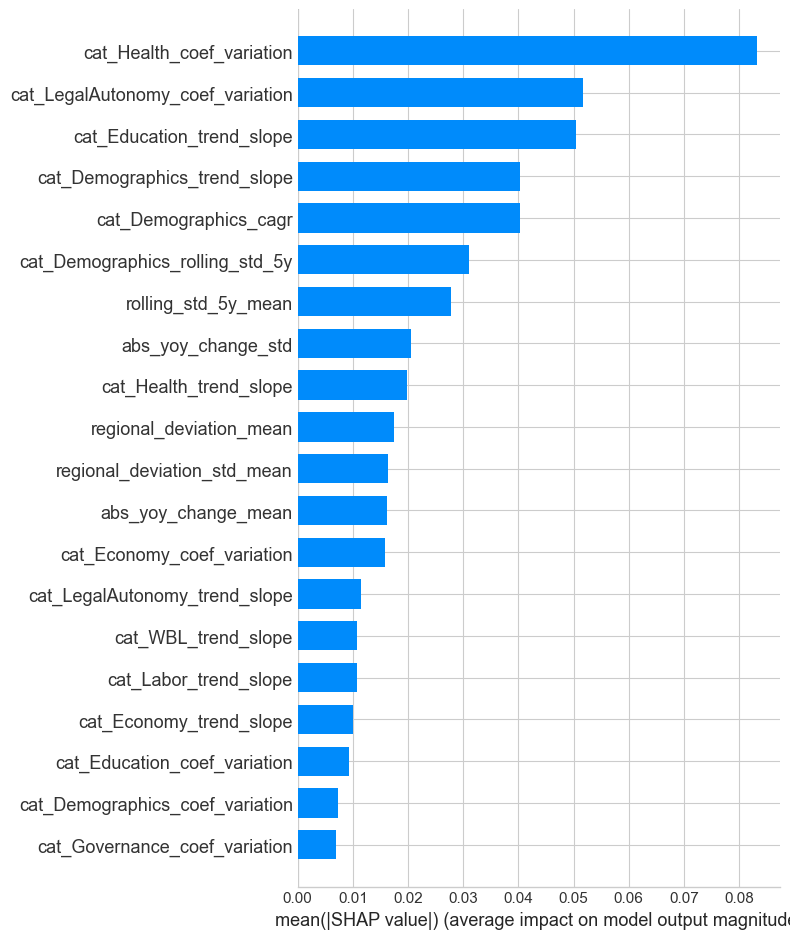

<Figure size 640x480 with 0 Axes>

In [58]:
# Extract SHAP values for class 1 (anomaly)
shap_class1 = shap_values[1].T  # transpose to (samples, features)

# Sanity check
print("SHAP shape:", shap_class1.shape)
print("X shape:", X_test_transformed.shape)

# Global importance
shap.summary_plot(
    shap_class1,
    X_test_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

plt.savefig(f"{OUTPUT_DIR}shap_1.png", dpi=300)

### Why did the model flag this specific country in this specific year as high-risk?

In [59]:
# 1) Predict on test
y_pred = rf_pipeline.predict(X_test_raw)

# Probability for class 1 (anomaly_flag=1)
y_proba = rf_pipeline.predict_proba(X_test_raw)[:, 1]

# 2) Build a case table (keep index aligned with X_test_raw)
cases = df.loc[X_test_raw.index, ["country_name", "year"]].copy()

cases["y_true"] = y_test.values
cases["y_pred"] = y_pred
cases["p1"] = y_proba


print("Cases shape:", cases.shape)
print("\nConfusion counts:")
print(pd.crosstab(cases["y_true"], cases["y_pred"], rownames=["y_true"], colnames=["y_pred"]))

cases.sort_values("p1", ascending=False).head(10)

Cases shape: (90, 5)

Confusion counts:
y_pred   0   1
y_true        
0       75   0
1        0  15


,country_name,year,y_true,y_pred,p1
406,West Bank and Gaza,2022,1,1,0.981793
238,Morocco,2022,1,1,0.976830
235,Morocco,2019,1,1,0.976533
403,West Bank and Gaza,2019,1,1,0.971959
405,West Bank and Gaza,2021,1,1,0.969462
404,West Bank and Gaza,2020,1,1,0.960826
239,Morocco,2023,1,1,0.957649
236,Morocco,2020,1,1,0.948409
237,Morocco,2021,1,1,0.943457
187,Lebanon,2019,1,1,0.936659


In [60]:
# 1) High-confidence True Positive
tp_high = cases[
    (cases["y_true"] == 1) & (cases["y_pred"] == 1)
].sort_values("p1", ascending=False).iloc[0]

# 2) Borderline True Positive (lowest probability among positives)
tp_borderline = cases[
    (cases["y_true"] == 1) & (cases["y_pred"] == 1)
].sort_values("p1", ascending=True).iloc[0]

# 3) High-confidence True Negative
tn_high = cases[
    (cases["y_true"] == 0) & (cases["y_pred"] == 0)
].sort_values("p1", ascending=True).iloc[0]

print(tp_high)
print(tp_borderline)
print(tn_high)

country_name    West Bank and Gaza
year                          2022
y_true                           1
y_pred                           1
p1                        0.981793
Name: 406, dtype: object
country_name     Lebanon
year                2021
y_true                 1
y_pred                 1
p1              0.835697
Name: 189, dtype: object
country_name    Oman
year            2019
y_true             0
y_pred             0
p1               0.0
Name: 259, dtype: object


In [61]:
pos_tp_high = cases.index.get_loc(tp_high.name)
pos_tp_border = cases.index.get_loc(tp_borderline.name)
pos_tn_high = cases.index.get_loc(tn_high.name)


X_tp_high = X_test_transformed[pos_tp_high].reshape(1, -1)
X_tp_border = X_test_transformed[pos_tp_border].reshape(1, -1)
X_tn_high = X_test_transformed[pos_tn_high].reshape(1, -1)



In [62]:
# SHAP values for all test samples (already class 1)
shap_all = explainer.shap_values(X_test_transformed)

print("SHAP shape:", shap_all.shape)
print("X_test shape:", X_test_transformed.shape)


SHAP shape: (90, 78, 2)
X_test shape: (90, 78)


In [63]:
shap_pos = shap_all[:, :, 1]   # shape: (90, 78)


In [64]:
i_tp_high = cases.index.get_loc(tp_high.name)
i_tp_border = cases.index.get_loc(tp_borderline.name)
i_tn_high = cases.index.get_loc(tn_high.name)

shap_tp_high = shap_pos[i_tp_high]
shap_tp_border = shap_pos[i_tp_border]
shap_tn_high = shap_pos[i_tn_high]



#### High-confidence true positive

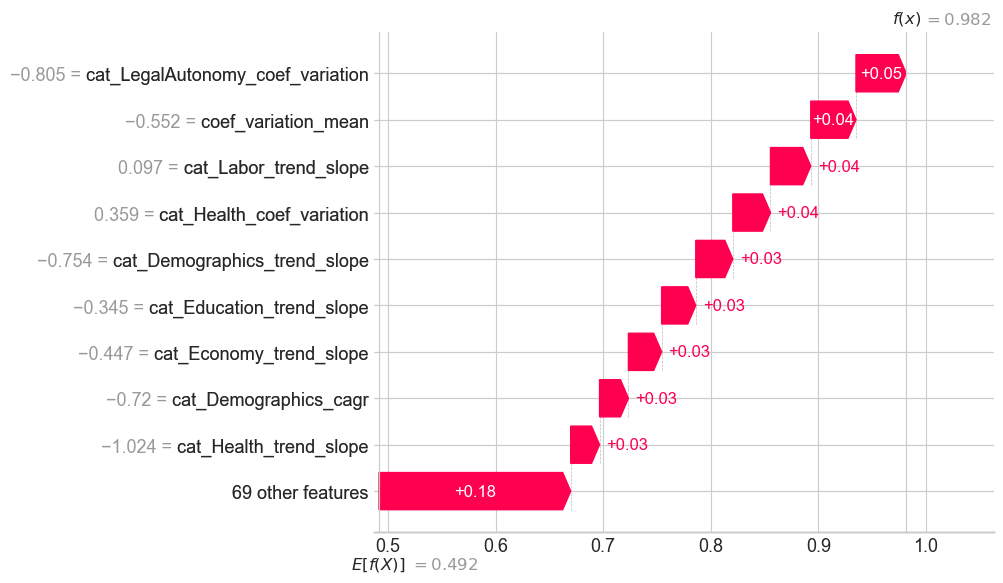

In [65]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_tp_high,
        base_values=explainer.expected_value[1],
        data=X_test_transformed[i_tp_high],
        feature_names=feature_names
    )
)


#### Borderline Case

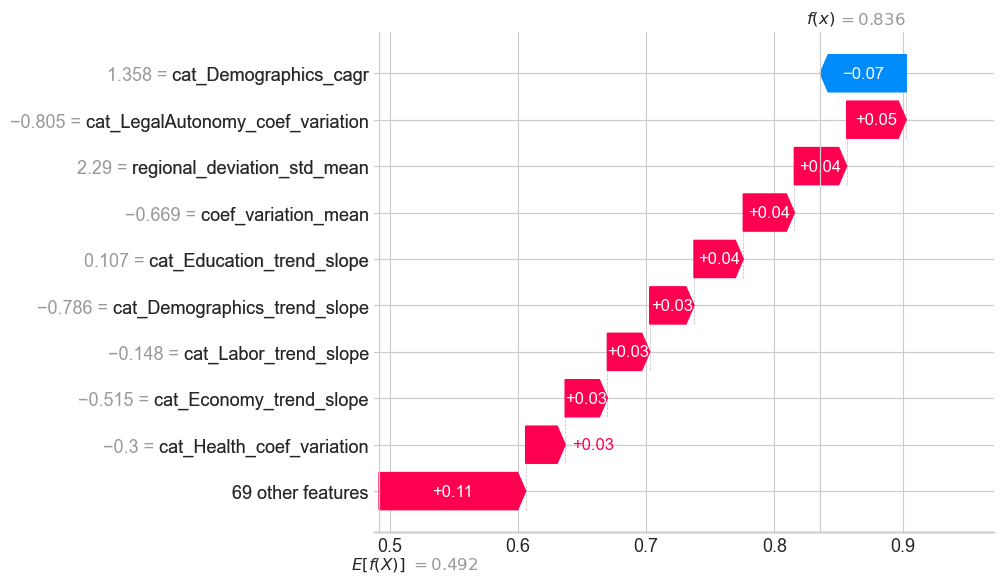

In [66]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_tp_border,
        base_values=explainer.expected_value[1],
        data=X_test_transformed[i_tp_border],
        feature_names=feature_names
    )
)


#### High-confidence true negative (still using class 1 SHAP)

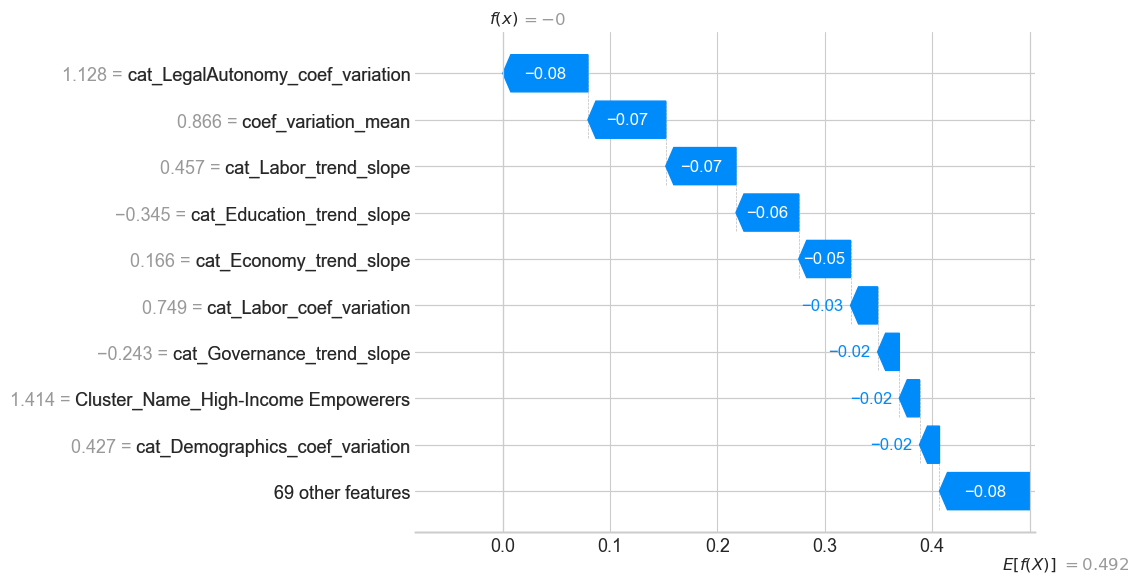

In [67]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_tn_high,
        base_values=explainer.expected_value[1],
        data=X_test_transformed[i_tn_high],
        feature_names=feature_names
    )
)



### Compare SHAP Drivers vs Events

In [68]:
# Map original index → test position
test_index_map = {
    idx: pos for pos, idx in enumerate(X_test_raw.index)
}


In [69]:
TOP_K = 5
records = []

for i, row in cases.iterrows():
    if row['y_pred'] != 1:
        continue
    
    pos = test_index_map[i]          # convert original index → test position
    shap_vals = shap_all[pos, :, 1] 
    top_idx = np.argsort(np.abs(shap_vals))[-TOP_K:][::-1]
    
    for rank, j in enumerate(top_idx, start=1):
        records.append({
            "country_name": row["country_name"],
            "year": row["year"],
            "predicted_prob": row["p1"],
            "feature": feature_names[j],
            "shap_value": shap_vals[j],
            "rank": rank
        })
shap_drivers = pd.DataFrame(records)
shap_drivers["direction"] = np.where(
    shap_drivers["shap_value"] > 0,
    "pushes toward high risk",
    "pushes toward low risk"
)

shap_drivers.head()

,country_name,year,predicted_prob,feature,shap_value,rank,direction
0,Lebanon,2019,0.936659,cat_LegalAutonomy_coef_variation,0.047653,1,pushes toward high risk
1,Lebanon,2019,0.936659,regional_deviation_std_mean,0.044392,2,pushes toward high risk
2,Lebanon,2019,0.936659,coef_variation_mean,0.042529,3,pushes toward high risk
3,Lebanon,2019,0.936659,cat_Education_trend_slope,0.041244,4,pushes toward high risk
4,Lebanon,2019,0.936659,cat_Demographics_trend_slope,0.036935,5,pushes toward high risk


In [70]:
shap_drivers.loc[shap_drivers['direction'] == 'pushes toward low risk']

,country_name,year,predicted_prob,feature,shap_value,rank,direction
6,Lebanon,2020,0.863205,cat_Demographics_cagr,-0.043348,2,pushes toward low risk
10,Lebanon,2021,0.835697,cat_Demographics_cagr,-0.067109,1,pushes toward low risk
70,West Bank and Gaza,2023,0.836823,cat_Demographics_cagr,-0.084204,1,pushes toward low risk


In [71]:
shap_drivers.groupby("feature").shap_value.mean().sort_values(ascending=False)


feature
cat_LegalAutonomy_coef_variation    0.045826
regional_deviation_std_mean         0.041744
coef_variation_mean                 0.041218
cat_Economy_trend_slope             0.041125
cat_Education_trend_slope           0.037415
cat_Labor_trend_slope               0.036617
cat_Demographics_trend_slope        0.035232
cat_Health_coef_variation           0.034928
cat_Demographics_cagr              -0.064887
Name: shap_value, dtype: float64

In [72]:
event_cols = [
    "flag_global_crisis",
    "flag_country_conflict",
    "flag_country_crisis",
    "flag_regional_crisis",
    "flag_reform_period"
]

event_lookup = (
    df[["country_name", "year"] + event_cols]
    .drop_duplicates()
)


In [73]:
shap_events = shap_drivers.merge(
    event_lookup,
    on=["country_name", "year"],
    how="left"
)


## During global crises, what SHAP drivers dominate?

In [74]:
shap_events.loc[
    shap_events["flag_global_crisis"] == 1
].groupby("feature").shap_value.mean().sort_values(ascending=False)


feature
cat_LegalAutonomy_coef_variation    0.046060
regional_deviation_std_mean         0.042321
coef_variation_mean                 0.041570
cat_Economy_trend_slope             0.041444
cat_Education_trend_slope           0.037456
cat_Labor_trend_slope               0.036914
cat_Health_coef_variation           0.034855
cat_Demographics_trend_slope        0.034728
cat_Demographics_cagr              -0.043348
Name: shap_value, dtype: float64

## During reform periods, what changes?

In [75]:
shap_events.loc[
    shap_events['flag_reform_period'] == 1
].groupby("feature").shap_value.mean().sort_values(ascending=False)

Series([], Name: shap_value, dtype: float64)

## Do conflict years look different from reform years?

In [76]:
conflict_drivers = shap_events.loc[
    shap_events["flag_country_conflict"] == 1
].groupby("feature").shap_value.mean()

reform_drivers = shap_events.loc[
    shap_events["flag_reform_period"] == 1
].groupby("feature").shap_value.mean()

print((conflict_drivers - reform_drivers).sort_values(ascending=False))


Series([], Name: shap_value, dtype: float64)


In [77]:
# How many test rows have each flag?
cases_with_flags = cases.merge(
    df[["country_name", "year", 
        "flag_global_crisis", 
        "flag_reform_period", 
        "flag_country_conflict"]],
    on=["country_name", "year"],
    how="left"
)

cases_with_flags[[
    "flag_global_crisis",
    "flag_reform_period",
    "flag_country_conflict"
]].sum()


flag_global_crisis       36
flag_reform_period        3
flag_country_conflict     0
dtype: int64

## Year Robustness 
### Does the model rely on very recent years only, or does the same explanatory logic hold when trained on earlier data?

In [78]:
CUTOFF_YEARS = [2009,2014,2016,2017,2018,2019,2020]

In [79]:
from sklearn import clone


def run_year_cutoff_rf_shap(
    cutoff_year,
    X,
    y_class,
    df,
    rf_template,
    feature_names,
    shap_sample_size=None
):
    """
    Train RF using data <= cutoff_year and explain predictions on > cutoff_year
    """

    # --- 1. Year-based split ---
    train_mask = df["year"] <= cutoff_year
    test_mask  = df["year"] > cutoff_year

    X_train = X.loc[train_mask]
    y_train = y_class.loc[train_mask]

    X_test  = X.loc[test_mask]
    y_test  = y_class.loc[test_mask]

    # Safety check
    if X_test.shape[0] == 0:
        raise ValueError(f"No test data after cutoff {cutoff_year}")

    # --- 2. Train model ---
    rf = clone(rf_template)
    rf.fit(X_train, y_train)

    # --- 3. Predictions ---
    y_prob = rf.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    # --- 4. SHAP explainer ---
    explainer = shap.TreeExplainer(rf)

    # Optional sampling for speed
    if shap_sample_size is not None and X_test.shape[0] > shap_sample_size:
        X_shap = X_test.sample(shap_sample_size, random_state=42)
    else:
        X_shap = X_test

    shap_values = explainer.shap_values(X_shap)

    # Class 1 SHAP values (binary RF)
    shap_pos = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values[1]

    # --- 5. Global SHAP summary ---
    shap_summary = (
        pd.DataFrame(shap_pos, columns=feature_names)
        .abs()
        .mean()
        .sort_values(ascending=False)
        .reset_index()
        .rename(columns={"index": "feature", 0: "mean_abs_shap"})
    )

    # --- 6. Package outputs ---
    results = {
        "cutoff_year": cutoff_year,
        "train_size": X_train.shape[0],
        "test_size": X_test.shape[0],
        "positive_rate": y_pred.mean(),
        "mean_pred_prob": y_prob.mean(),
        "shap_summary": shap_summary,
        "model": rf
    }

    return results


In [80]:
cutoff_years = [2009,2014,2016,2017,2018,2019,2020]

all_results = []

for cutoff in cutoff_years:
    res = run_year_cutoff_rf_shap(
        cutoff_year=cutoff,
        X=X,
        y_class=y_class,
        df=df,
        rf_template=rf,          # your RF definition
        feature_names=X.columns.tolist(),
        shap_sample_size=200     # optional
    )
    all_results.append(res)


In [81]:
all_results_df = pd.DataFrame(all_results)

In [82]:
all_results_df 

,cutoff_year,train_size,test_size,positive_rate,mean_pred_prob,shap_summary,model
0,2009,180,252,0.166667,0.175974,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."
1,2014,270,162,0.166667,0.166357,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."
2,2016,306,126,0.166667,0.173629,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."
3,2017,324,108,0.166667,0.171457,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."
4,2018,342,90,0.166667,0.179111,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."
5,2019,360,72,0.166667,0.180198,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."
6,2020,378,54,0.166667,0.174036,feature mean_abs...,"(DecisionTreeClassifier(max_features='sqrt', m..."


In [83]:
shap_long = []

for res in all_results:
    tmp = res["shap_summary"].copy()
    tmp["cutoff_year"] = res["cutoff_year"]
    shap_long.append(tmp)

shap_long = pd.concat(shap_long, ignore_index=True)


In [84]:
shap_long.query("feature == 'cat_LegalAutonomy_coef_variation'")


,feature,mean_abs_shap,cutoff_year
0,cat_LegalAutonomy_coef_variation,0.053791,2009
78,cat_LegalAutonomy_coef_variation,0.055851,2014
156,cat_LegalAutonomy_coef_variation,0.055905,2016
235,cat_LegalAutonomy_coef_variation,0.051698,2017
312,cat_LegalAutonomy_coef_variation,0.055386,2018
390,cat_LegalAutonomy_coef_variation,0.052634,2019
469,cat_LegalAutonomy_coef_variation,0.052212,2020


In [85]:
shap_long["rank"] = shap_long.groupby("cutoff_year")["mean_abs_shap"].rank(ascending=False)

shap_long.pivot(
    index="feature",
    columns="cutoff_year",
    values="rank"
).sort_values(by=cutoff_years[-1])


cutoff_year,2009,2014,2016,2017,2018,2019,2020
feature,,,,,,,
cat_Health_coef_variation,3.0,2.0,2.0,1.0,2.0,2.0,1.0
cat_LegalAutonomy_coef_variation,1.0,1.0,1.0,2.0,1.0,1.0,2.0
cat_Labor_trend_slope,2.0,4.0,3.0,3.0,3.0,3.0,3.0
coef_variation_mean,5.0,3.0,4.0,4.0,4.0,4.0,4.0
cat_Education_trend_slope,4.0,6.0,5.0,5.0,5.0,5.0,5.0
...,...,...,...,...,...,...,...
cat_Labor_dip,56.0,68.5,68.5,68.5,55.0,51.0,69.5
cat_Governance_dip,51.0,52.0,54.0,68.5,51.0,70.0,69.5
cat_Governance_spike,68.5,68.5,68.5,68.5,68.5,70.0,69.5


In [86]:
shap_drift = []

for res in all_results:
    df_tmp = res["shap_summary"].copy()
    df_tmp["cutoff_year"] = res["cutoff_year"]
    shap_drift.append(df_tmp)
shap_drift = pd.concat(shap_drift, ignore_index=True)

In [87]:
shap_drift.to_csv(OUTPUT_DIR / "shap_drift_by_cutoff_year.csv", index=False)

### Viz A - Does a feature’s importance grow, shrink, or stay stable over time?

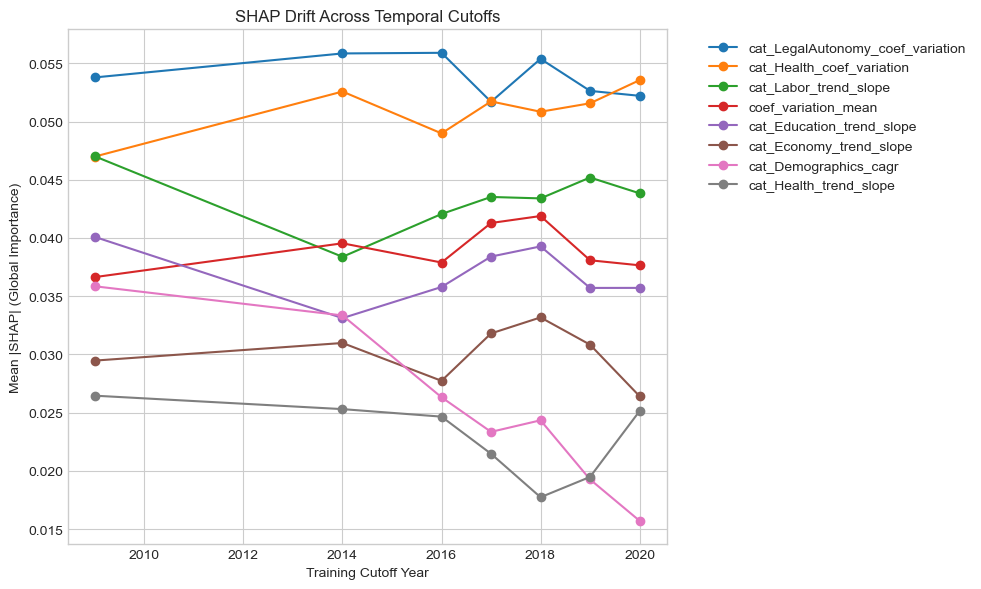

In [88]:
TOP_FEATURES = 8

top_features = (
    shap_drift
    .groupby("feature")["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
    .head(TOP_FEATURES)
    .index
)

plot_df = shap_drift[shap_drift["feature"].isin(top_features)]

plt.figure(figsize=(10, 6))
for feat in top_features:
    subset = plot_df[plot_df["feature"] == feat]
    plt.plot(
        subset["cutoff_year"],
        subset["mean_abs_shap"],
        marker="o",
        label=feat
    )

plt.xlabel("Training Cutoff Year")
plt.ylabel("Mean |SHAP| (Global Importance)")
plt.title("SHAP Drift Across Temporal Cutoffs")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}shap_drift", dpi=300)
plt.show()


### Viz B - Does the ranking of features change across cutoffs?

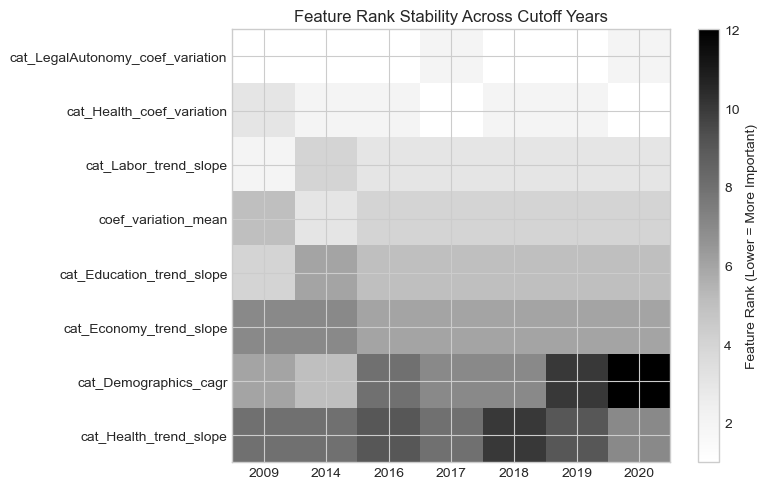

In [89]:
shap_drift["rank"] = (
    shap_drift
    .groupby("cutoff_year")["mean_abs_shap"]
    .rank(ascending=False)
)

rank_pivot = shap_drift.pivot(
    index="feature",
    columns="cutoff_year",
    values="rank"
)

rank_pivot = rank_pivot.loc[top_features]

plt.figure(figsize=(8, 5))
plt.imshow(rank_pivot, aspect="auto")
plt.colorbar(label="Feature Rank (Lower = More Important)")
plt.yticks(range(len(rank_pivot.index)), rank_pivot.index)
plt.xticks(range(len(rank_pivot.columns)), rank_pivot.columns)
plt.title("Feature Rank Stability Across Cutoff Years")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}shap_rank", dpi=300)
plt.show()


In [90]:
rank_pivot.to_csv(OUTPUT_DIR / "shap_rank_stability.csv")

### Viz C - Is the model relying on more or fewer features over time?

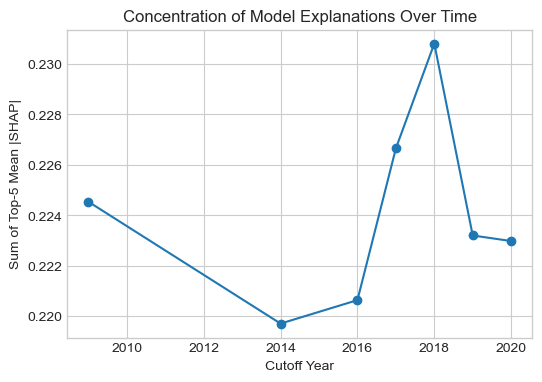

In [91]:
mass_df = (
    shap_drift
    .groupby("cutoff_year")["mean_abs_shap"]
    .apply(lambda x: x.head(5).sum())
    .reset_index(name="top5_shap_mass")
)

plt.figure(figsize=(6, 4))
plt.plot(
    mass_df["cutoff_year"],
    mass_df["top5_shap_mass"],
    marker="o"
)
plt.xlabel("Cutoff Year")
plt.ylabel("Sum of Top-5 Mean |SHAP|")
plt.title("Concentration of Model Explanations Over Time")
plt.grid(True)
plt.savefig(f"{OUTPUT_DIR}shap_mass_concentration", dpi=300)
plt.show()



In [92]:
mass_df.to_csv(OUTPUT_DIR / "shap_mass_concentration.csv")

## Seed Robustness
### Are the SHAP explanations stable with respect to the model’s random initialization?

In [93]:
SEEDS = [0, 1, 2, 5, 10, 42, 99]
CUTOFF_YEAR = 2018

seed_results = []

for seed in SEEDS:
    # 1. Train-test split (already fixed by cutoff year)
    train_mask = df["year"] <= CUTOFF_YEAR
    test_mask  = df["year"] >  CUTOFF_YEAR

    X_train = X.loc[train_mask]
    y_train = y_class.loc[train_mask]

    X_test  = X.loc[test_mask]
    y_test  = y_class.loc[test_mask]

    # 2. Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=3,
        class_weight="balanced",
        random_state=seed,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    # 3. SHAP
    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_test)[1]

    # Ensure SHAP is (n_samples, n_features)
    if shap_vals.shape[0] != X_test.shape[0]:
        shap_vals = shap_vals.T

    shap_summary = (
        pd.DataFrame({
            "feature": X_test.columns,
            "mean_abs_shap": np.abs(shap_vals).mean(axis=0)
        })
        .sort_values("mean_abs_shap", ascending=False)
    )

    seed_results.append({
        "seed": seed,
        "shap_summary": shap_summary
    })



In [94]:
shap_seed_long = []

for res in seed_results:
    tmp = res["shap_summary"].copy()
    tmp["seed"] = res["seed"]
    shap_seed_long.append(tmp)

shap_seed_long = pd.concat(shap_seed_long, ignore_index=True)


In [95]:
shap_seed_long.to_csv(OUTPUT_DIR / "shap_by_seed.csv", index=False)

### V1 - SHAP Magnitude Drift Across Seeds

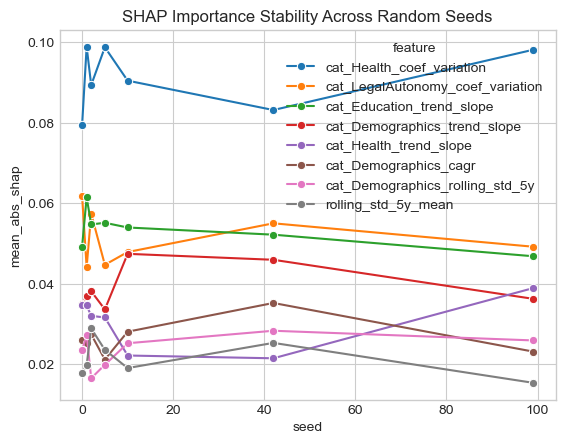

In [96]:
TOP_FEATURES = (
    shap_seed_long
    .groupby("feature")["mean_abs_shap"]
    .mean()
    .sort_values(ascending=False)
    .head(8)
    .index
)

plot_df = shap_seed_long.query("feature in @TOP_FEATURES")

sns.lineplot(
    data=plot_df,
    x="seed",
    y="mean_abs_shap",
    hue="feature",
    marker="o"
)
plt.title("SHAP Importance Stability Across Random Seeds")
plt.savefig(f"{OUTPUT_DIR}shap_seed_stability", dpi=300)
plt.show()


### V3 - Feature Rank Stability Across Seeds

In [97]:
shap_seed_long["rank"] = (
    shap_seed_long
    .groupby("seed")["mean_abs_shap"]
    .rank(ascending=False)
)

rank_pivot = shap_seed_long.pivot(
    index="feature",
    columns="seed",
    values="rank"
)

rank_pivot.loc[TOP_FEATURES]


seed,0,1,2,5,10,42,99
feature,,,,,,,
cat_Health_coef_variation,1.0,1.0,1.0,1.0,1.0,1.0,1.0
cat_Education_trend_slope,3.0,2.0,3.0,2.0,2.0,3.0,3.0
cat_LegalAutonomy_coef_variation,2.0,3.0,2.0,3.0,3.0,2.0,2.0
cat_Demographics_trend_slope,4.0,4.0,4.0,4.0,4.0,4.0,5.0
cat_Health_trend_slope,5.0,5.0,5.0,5.0,7.0,8.0,4.0
cat_Demographics_cagr,6.0,8.0,7.0,9.0,5.0,5.0,8.0
cat_Demographics_rolling_std_5y,7.0,7.0,12.0,11.0,6.0,6.0,7.0
rolling_std_5y_mean,12.0,10.0,6.0,7.0,9.0,7.0,12.0


In [98]:
rank_pivot.to_csv(OUTPUT_DIR / "shap_rank_by_seed.csv")

### V3 - Explanation Concentration Across Seeds

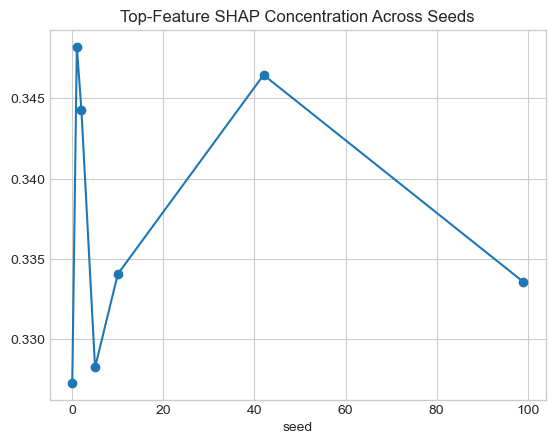

In [99]:
concentration = (
    shap_seed_long
    .query("feature in @TOP_FEATURES")
    .groupby("seed")["mean_abs_shap"]
    .sum()
)

concentration.plot(marker="o", title="Top-Feature SHAP Concentration Across Seeds")
plt.savefig(f"{OUTPUT_DIR}shap_seed_concentration", dpi=300)
plt.show()


## RF Capacity Reduction
### Are the explanations stable because the signal is real — or because the model is flexible enough to always find something?

In [100]:
CAPACITY_TIERS = {
    "T0_reference": dict(
        max_depth=None,
        min_samples_leaf=5
    ),
    "T1_mild": dict(
        max_depth=12,
        min_samples_leaf=8
    ),
    "T2_moderate": dict(
        max_depth=8,
        min_samples_leaf=12
    ),
    "T3_strong": dict(
        max_depth=5,
        min_samples_leaf=20
    )
}


In [101]:
shap_capacity_long = []

for tier_name, params in CAPACITY_TIERS.items():
    print("\n---")
    print("ENTERING tier:", tier_name)

    rf = RandomForestClassifier(
        n_estimators=300,
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf.fit(X_train, y_train)

    explainer = shap.TreeExplainer(rf)
    shap_vals = explainer.shap_values(X_test)
    
    # Handle both SHAP output formats robustly
    if isinstance(shap_vals, list):
    # old-style: list of arrays
        shap_vals_pos = shap_vals[1]
    else:
    # new-style: (n_samples, n_features, n_classes)
        shap_vals_pos = shap_vals[:, :, 1]

    print("shap_vals type:", type(shap_vals))
    print("shap_vals shape:", np.array(shap_vals).shape)

    shap_vals = shap_vals[1] if isinstance(shap_vals, list) else shap_vals

    print("post-select SHAP shape:", shap_vals.shape)
    print("X_test shape:", X_test.shape)

    if shap_vals.shape[1] != X_test.shape[1]:
        print("⚠️ SHAPE MISMATCH — SKIPPING APPEND")
        continue

    print("✅ APPENDING tier:", tier_name)

    mean_abs_shap = np.abs(shap_vals_pos).mean(axis=0)

    shap_summary = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

    shap_summary["rank"] = np.arange(1, len(shap_summary) + 1)
    shap_summary["tier"] = tier_name

    shap_capacity_long.append(shap_summary)




---
ENTERING tier: T0_reference
shap_vals type: <class 'numpy.ndarray'>
shap_vals shape: (90, 78, 2)
post-select SHAP shape: (90, 78, 2)
X_test shape: (90, 78)
✅ APPENDING tier: T0_reference

---
ENTERING tier: T1_mild
shap_vals type: <class 'numpy.ndarray'>
shap_vals shape: (90, 78, 2)
post-select SHAP shape: (90, 78, 2)
X_test shape: (90, 78)
✅ APPENDING tier: T1_mild

---
ENTERING tier: T2_moderate
shap_vals type: <class 'numpy.ndarray'>
shap_vals shape: (90, 78, 2)
post-select SHAP shape: (90, 78, 2)
X_test shape: (90, 78)
✅ APPENDING tier: T2_moderate

---
ENTERING tier: T3_strong
shap_vals type: <class 'numpy.ndarray'>
shap_vals shape: (90, 78, 2)
post-select SHAP shape: (90, 78, 2)
X_test shape: (90, 78)
✅ APPENDING tier: T3_strong


In [102]:
shap_capacity_long_df = pd.concat(shap_capacity_long, ignore_index=True)
shap_capacity_long_df["tier"].value_counts()


tier
T0_reference    78
T1_mild         78
T2_moderate     78
T3_strong       78
Name: count, dtype: int64

In [115]:
shap_capacity_long_df

,feature,mean_abs_shap,rank,tier
0,cat_LegalAutonomy_coef_variation,0.055386,1,T0_reference
1,cat_Health_coef_variation,0.050843,2,T0_reference
2,cat_Labor_trend_slope,0.043402,3,T0_reference
3,coef_variation_mean,0.041887,4,T0_reference
4,cat_Education_trend_slope,0.039278,5,T0_reference
...,...,...,...,...
307,cat_Labor_dip,0.000000,74,T3_strong
308,cat_LegalAutonomy_dip,0.000000,75,T3_strong
309,cat_WBL_dip,0.000000,76,T3_strong
310,abs_yoy_change_median,0.000000,77,T3_strong


In [104]:
shap_capacity_long_df.tail()

,feature,mean_abs_shap,rank,tier
307,cat_Labor_dip,0.0,74,T3_strong
308,cat_LegalAutonomy_dip,0.0,75,T3_strong
309,cat_WBL_dip,0.0,76,T3_strong
310,abs_yoy_change_median,0.0,77,T3_strong
311,Cluster_Name_Palestine,0.0,78,T3_strong


#### Rank Stability of Top Features

In [107]:
TOP_K = 10

rank_pivot = (
    shap_capacity_long_df
    .query("rank <= @TOP_K")
    .pivot(index="feature", columns="tier", values="rank")
    .sort_values(by="T0_reference")
)
rank_pivot.to_csv(OUTPUT_DIR/'tiers_shap_rank.csv')
rank_pivot


tier,T0_reference,T1_mild,T2_moderate,T3_strong
feature,,,,
cat_LegalAutonomy_coef_variation,1,1,1,1
cat_Health_coef_variation,2,2,2,2
cat_Labor_trend_slope,3,3,3,3
coef_variation_mean,4,4,4,5
cat_Education_trend_slope,5,5,5,4
cat_Economy_trend_slope,6,6,6,6
cat_Demographics_cagr,7,7,7,7
cat_Demographics_trend_slope,8,9,9,9
regional_deviation_std_mean,9,8,8,8


#### Rank Volatility (Quantified)

In [108]:
rank_volatility = (
    rank_pivot
    .dropna()
    .assign(rank_std=lambda df: df.std(axis=1))
    .sort_values("rank_std", ascending=False)
)
rank_volatility.to_csv(OUTPUT_DIR/'tiers_shap_rank_volatility.csv')
rank_volatility.head(10)


tier,T0_reference,T1_mild,T2_moderate,T3_strong,rank_std
feature,,,,,
coef_variation_mean,4,4,4,5,0.5
cat_Education_trend_slope,5,5,5,4,0.5
cat_Demographics_trend_slope,8,9,9,9,0.5
regional_deviation_std_mean,9,8,8,8,0.5
cat_LegalAutonomy_coef_variation,1,1,1,1,0.0
cat_Health_coef_variation,2,2,2,2,0.0
cat_Labor_trend_slope,3,3,3,3,0.0
cat_Economy_trend_slope,6,6,6,6,0.0
cat_Demographics_cagr,7,7,7,7,0.0


#### SHAP Magnitude Drift

In [109]:
TOP_FEATURES = (
    shap_capacity_long_df
    .query("tier == 'T0_reference'")
    .sort_values("rank")
    .head(8)["feature"]
    .tolist()
)

shap_mag_pivot = (
    shap_capacity_long_df
    .query("feature in @TOP_FEATURES")
    .pivot(index="feature", columns="tier", values="mean_abs_shap")
)

shap_mag_pivot.to_csv(OUTPUT_DIR/'tiers_shap_magnitude.csv')
shap_mag_pivot


tier,T0_reference,T1_mild,T2_moderate,T3_strong
feature,,,,
cat_Demographics_cagr,0.024343,0.022565,0.024735,0.026602
cat_Demographics_trend_slope,0.021834,0.019933,0.020767,0.022360
cat_Economy_trend_slope,0.033179,0.034640,0.032081,0.030351
cat_Education_trend_slope,0.039278,0.038043,0.039218,0.042543
cat_Health_coef_variation,0.050843,0.052978,0.048862,0.044931
cat_Labor_trend_slope,0.043402,0.044868,0.044719,0.043905
cat_LegalAutonomy_coef_variation,0.055386,0.054276,0.054389,0.049469
coef_variation_mean,0.041887,0.042990,0.042952,0.042173


#### V1 - SHAP Response to Capacity
##### Does explanatory signal degrade smoothly or break abruptly?

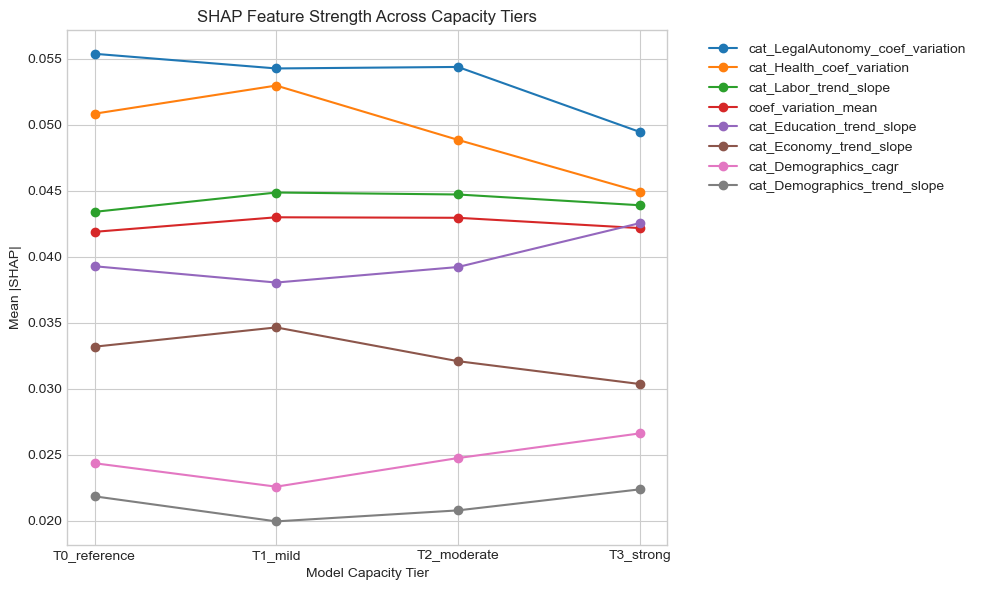

In [111]:
plt.figure(figsize=(10, 6))

for feature in TOP_FEATURES:
    subset = shap_capacity_long_df[shap_capacity_long_df["feature"] == feature]
    plt.plot(
        subset["tier"],
        subset["mean_abs_shap"],
        marker="o",
        label=feature
    )

plt.title("SHAP Feature Strength Across Capacity Tiers")
plt.ylabel("Mean |SHAP|")
plt.xlabel("Model Capacity Tier")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}tier_shap_strength", dpi=300)
plt.show()


#### Concentration of Explanation Power
##### Does the model rely on fewer features when constrained?


In [113]:
concentration = (
    shap_capacity_long_df
    .groupby("tier")
    .apply(lambda df: df.sort_values("rank").head(5)["mean_abs_shap"].sum())
    .rename("top5_shap_share")
)

concentration


/var/folders/ln/0dzfh__x22s4sjj8k1k2jw880000gn/T/ipykernel_32821/2359425545.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: df.sort_values("rank").head(5)["mean_abs_shap"].sum())


tier
T0_reference    0.230797
T1_mild         0.233155
T2_moderate     0.230140
T3_strong       0.223020
Name: top5_shap_share, dtype: float64

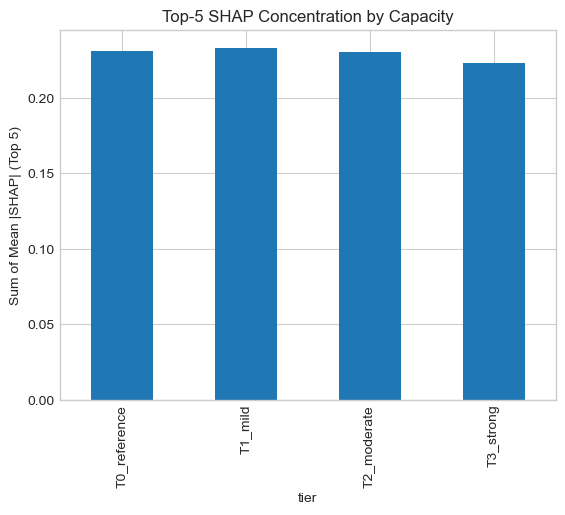

In [114]:
concentration.plot(kind="bar", title="Top-5 SHAP Concentration by Capacity")
plt.ylabel("Sum of Mean |SHAP| (Top 5)")
plt.savefig(f"{OUTPUT_DIR}tier_feature_concentration", dpi=300)
plt.show()


# Exports for Country Matrix

### Country Risk Tiers

In [116]:
cases.head()


,country_name,year,y_true,y_pred,p1
19,Algeria,2019,0,0,0.008024
20,Algeria,2020,0,0,0.004135
21,Algeria,2021,0,0,0.004135
22,Algeria,2022,0,0,0.009593
23,Algeria,2023,0,0,0.007212


In [120]:
country_risk_summary = (
    cases
    .groupby("country_name")
    .agg(
        high_risk_rate=("y_pred", "mean"),
        avg_risk_prob=("p1", "mean"),
        n_years=("year", "count")
    )
    .reset_index()
)
country_risk_summary['high_risk_rate'].value_counts()


high_risk_rate
0.0    15
1.0     3
Name: count, dtype: int64

In [121]:
classification_country_tiers = (
    country_risk_summary
    .assign(
        risk_tier=lambda df: np.where(
            df["high_risk_rate"] == 0,
            "T0_reference",
            "T3_strong"
        )
    )[["country_name", "risk_tier"]]
    .rename(columns={"country_name": "country"})
)
classification_country_tiers


,country,risk_tier
0,Algeria,T0_reference
1,Bahrain,T0_reference
2,"Egypt, Arab Rep.",T0_reference
3,"Iran, Islamic Rep.",T0_reference
4,Iraq,T0_reference
5,Jordan,T0_reference
6,Kuwait,T0_reference
7,Lebanon,T3_strong
8,Libya,T0_reference
9,Morocco,T3_strong


In [123]:
classification_country_tiers = classification_country_tiers.sort_values("country")

classification_country_tiers.to_csv(OUTPUT_DIR /
    "classification_country_tiers.csv",
    index=False
)


In [124]:
country_feature_shap = (
    shap_drivers
    .assign(abs_shap=lambda df: df["shap_value"].abs())
    .groupby(["country_name", "feature"], as_index=False)
    .agg(
        mean_abs_shap=("abs_shap", "mean"),
        mean_signed_shap=("shap_value", "mean")
    )
)
country_feature_shap.head()

,country_name,feature,mean_abs_shap,mean_signed_shap
0,Lebanon,cat_Demographics_cagr,0.055228,-0.055228
1,Lebanon,cat_Demographics_trend_slope,0.036135,0.036135
2,Lebanon,cat_Education_trend_slope,0.039801,0.039801
3,Lebanon,cat_LegalAutonomy_coef_variation,0.047391,0.047391
4,Lebanon,coef_variation_mean,0.041393,0.041393


In [127]:
country_feature_shap["rank"] = (
    country_feature_shap
    .groupby("country_name")["mean_abs_shap"]
    .rank(ascending=False, method="first")
)
country_feature_shap


,country_name,feature,mean_abs_shap,mean_signed_shap,rank
0,Lebanon,cat_Demographics_cagr,0.055228,-0.055228,1.0
1,Lebanon,cat_Demographics_trend_slope,0.036135,0.036135,6.0
2,Lebanon,cat_Education_trend_slope,0.039801,0.039801,5.0
3,Lebanon,cat_LegalAutonomy_coef_variation,0.047391,0.047391,2.0
4,Lebanon,coef_variation_mean,0.041393,0.041393,4.0
5,Lebanon,regional_deviation_std_mean,0.041744,0.041744,3.0
6,Morocco,cat_Economy_trend_slope,0.041125,0.041125,2.0
7,Morocco,cat_Education_trend_slope,0.035030,0.035030,5.0
8,Morocco,cat_Labor_trend_slope,0.036586,0.036586,4.0
9,Morocco,cat_LegalAutonomy_coef_variation,0.044139,0.044139,1.0


In [128]:
top_drivers_country = (
    country_feature_shap
    .query("rank <= 3")
    .sort_values(["country_name", "rank"])
)
top_drivers_country

,country_name,feature,mean_abs_shap,mean_signed_shap,rank
0,Lebanon,cat_Demographics_cagr,0.055228,-0.055228,1.0
3,Lebanon,cat_LegalAutonomy_coef_variation,0.047391,0.047391,2.0
5,Lebanon,regional_deviation_std_mean,0.041744,0.041744,3.0
9,Morocco,cat_LegalAutonomy_coef_variation,0.044139,0.044139,1.0
6,Morocco,cat_Economy_trend_slope,0.041125,0.041125,2.0
10,Morocco,coef_variation_mean,0.041067,0.041067,3.0
11,West Bank and Gaza,cat_Demographics_cagr,0.084204,-0.084204,1.0
15,West Bank and Gaza,cat_LegalAutonomy_coef_variation,0.045949,0.045949,2.0
16,West Bank and Gaza,coef_variation_mean,0.041195,0.041195,3.0


In [129]:
classification_SHAP_top_drivers = (
    top_drivers_country
    .pivot(index="country_name", columns="rank", values="feature")
    .reset_index()
    .rename(columns={
        "country_name": "country",
        1.0: "driver_1",
        2.0: "driver_2",
        3.0: "driver_3"
    })
)
classification_SHAP_top_drivers

rank,country,driver_1,driver_2,driver_3
0,Lebanon,cat_Demographics_cagr,cat_LegalAutonomy_coef_variation,regional_deviation_std_mean
1,Morocco,cat_LegalAutonomy_coef_variation,cat_Economy_trend_slope,coef_variation_mean
2,West Bank and Gaza,cat_Demographics_cagr,cat_LegalAutonomy_coef_variation,coef_variation_mean


In [130]:
classification_SHAP_top_drivers.to_csv(
    OUTPUT_DIR/"classification_SHAP_top_drivers.csv",
    index=False
)


In [131]:
directionality = country_feature_shap.assign(
    direction=lambda df: np.where(
        df["mean_signed_shap"] > 0,
        "risk_increasing",
        "protective"
    )
)
directionality.head()

,country_name,feature,mean_abs_shap,mean_signed_shap,rank,direction
0,Lebanon,cat_Demographics_cagr,0.055228,-0.055228,1.0,protective
1,Lebanon,cat_Demographics_trend_slope,0.036135,0.036135,6.0,risk_increasing
2,Lebanon,cat_Education_trend_slope,0.039801,0.039801,5.0,risk_increasing
3,Lebanon,cat_LegalAutonomy_coef_variation,0.047391,0.047391,2.0,risk_increasing
4,Lebanon,coef_variation_mean,0.041393,0.041393,4.0,risk_increasing


In [133]:
classification_SHAP_directionality = (
    directionality
    .query("rank <= 3")
    .sort_values(["country_name", "rank"])
    .rename(columns={"country_name": "country"})
    [["country", "feature", "direction"]]
)
classification_SHAP_directionality


,country,feature,direction
0,Lebanon,cat_Demographics_cagr,protective
3,Lebanon,cat_LegalAutonomy_coef_variation,risk_increasing
5,Lebanon,regional_deviation_std_mean,risk_increasing
9,Morocco,cat_LegalAutonomy_coef_variation,risk_increasing
6,Morocco,cat_Economy_trend_slope,risk_increasing
10,Morocco,coef_variation_mean,risk_increasing
11,West Bank and Gaza,cat_Demographics_cagr,protective
15,West Bank and Gaza,cat_LegalAutonomy_coef_variation,risk_increasing
16,West Bank and Gaza,coef_variation_mean,risk_increasing


In [134]:
classification_SHAP_directionality.to_csv(
   OUTPUT_DIR/ "classification_SHAP_directionality.csv",
    index=False
)
